In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import f_oneway


In [18]:

# Load the dataset
file_path = "AeroSCOPE_global_aviation_traffic_dataset_16_11.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Display basic info about the dataset

print(df.head())
print(df.info())



   Unnamed: 0 airline_iata acft_icao acft_class seymour_proxy source  seats  \
0           0           5V      PC12         TP          PC12    BTS    4.5   
1           1           5V      C208         TP          C208    BTS    4.5   
2           2           5V      PC12         TP          PC12    BTS    4.5   
3           3           5V      C208         TP          C208    BTS    4.5   
4           4           5V      PC12         TP          PC12    BTS    9.0   

   n_flights iata_departure iata_arrival  ...  arrival_country  \
0        0.5            05A          AET  ...               US   
1        0.5            05A          AKP  ...               US   
2        0.5            05A          AKP  ...               US   
3        0.5            05A          ARC  ...               US   
4        1.0            05A          CXF  ...               US   

   arrival_continent seats_no_est_scaling distance_km          ask  \
0                NaN                  4.5  223.942934  100

In [19]:
# Data Cleaning
print("Initial rows:", len(df))


df = df[df['co2'] > 0]  # Remove invalid emissions entries
df = df[df['distance_km'] > 0]  # Remove zero-distance flights
df = df[df['seats'] > 0]  # Remove invalid seat entries

print("Cleaned rows:", len(df))

# Add calculated metrics
df['co2_per_ask'] = df['co2'] / (df['seats'] * df['distance_km'])
df['load_factor'] = df['rpk'] / df['ask']  # Occupancy rate

df['fuel_efficiency'] = df['distance_km'] / df['fuel_burn']



df.head(n=20)

Initial rows: 293838
Cleaned rows: 286076


,Unnamed: 0,airline_iata,acft_icao,acft_class,seymour_proxy,source,seats,n_flights,iata_departure,iata_arrival,...,distance_km,ask,rpk,fuel_burn_seymour,fuel_burn,co2,domestic,co2_per_ask,load_factor,fuel_efficiency
0,0,5V,PC12,TP,PC12,BTS,4.5,0.5,05A,AET,...,223.942934,1007.743204,830.380400,124.087173,62.043586,196.057733,1,0.194551,0.824,3.609445
1,1,5V,C208,TP,C208,BTS,4.5,0.5,05A,AKP,...,162.423657,730.906457,602.266920,101.150619,50.575310,159.817978,1,0.218657,0.824,3.211521
2,2,5V,PC12,TP,PC12,BTS,4.5,0.5,05A,AKP,...,162.423657,730.906457,602.266920,104.747398,52.373699,165.500889,1,0.226432,0.824,3.101245
3,3,5V,C208,TP,C208,BTS,4.5,0.5,05A,ARC,...,125.368872,564.159925,464.867778,86.356979,43.178490,136.444027,1,0.241853,0.824,2.903503
4,4,5V,PC12,TP,PC12,BTS,9.0,1.0,05A,CXF,...,93.591691,842.325219,694.075981,83.360861,83.360861,263.420321,1,0.312730,0.824,1.122729
5,5,5V,C208,TP,C208,BTS,63.0,7.0,05A,FAI,...,307.552981,19375.837800,15965.690350,158.121254,1106.848776,3497.642131,1,0.180516,0.824,0.277864
6,6,5V,PC12,TP,PC12,BTS,45.0,5.0,05A,FAI,...,307.552981,13839.884140,11404.064530,150.712581,753.562906,2381.258782,1,0.172058,0.824,0.408132
7,7,2O,DHC2,PP,DHC2,BTS,30.0,5.0,06A,A43,...,29.532086,885.962580,730.033166,22.619534,113.097671,357.388639,1,0.403390,0.824,0.261120
8,8,2O,T37,PJ,C172,BTS,3.0,1.0,06A,A43,...,29.532086,88.596258,73.003317,14.948837,14.948837,47.238324,1,0.533186,0.824,1.975544
9,9,2O,DHC2,PP,DHC2,BTS,3.0,0.5,09A,A43,...,186.294352,558.883054,460.519637,43.785672,21.892836,69.181362,1,0.123785,0.824,8.509375


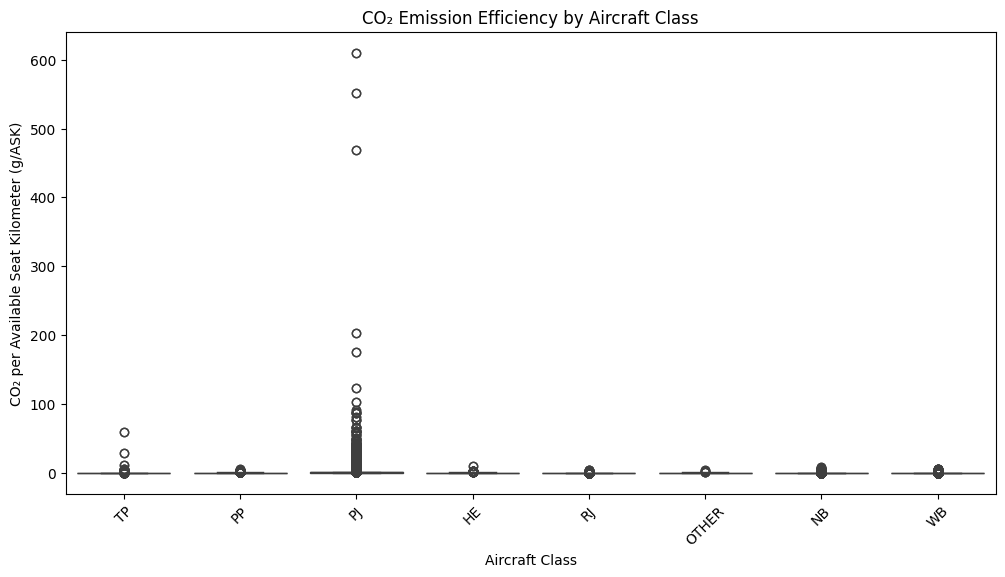

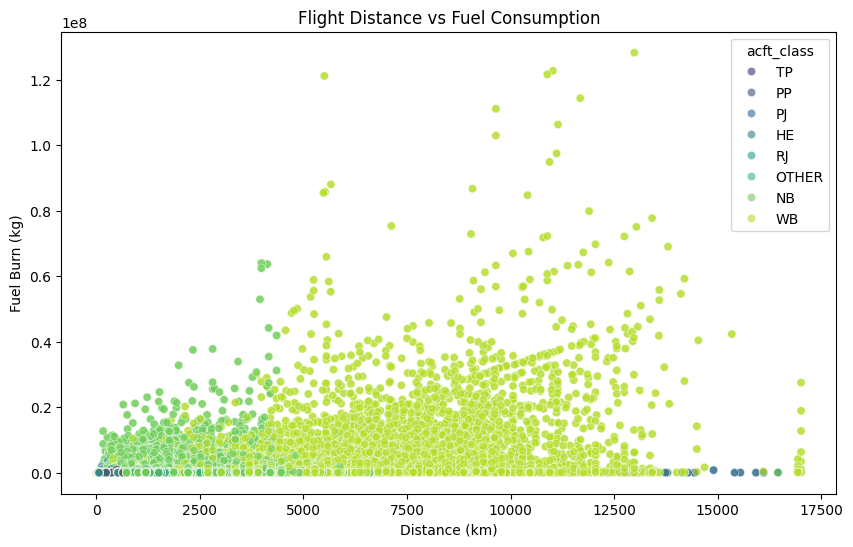

C:\Users\sakib\AppData\Local\Temp\ipykernel_13188\2140302869.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  load_factor_impact = df.groupby('load_category')['co2_per_ask'].mean()


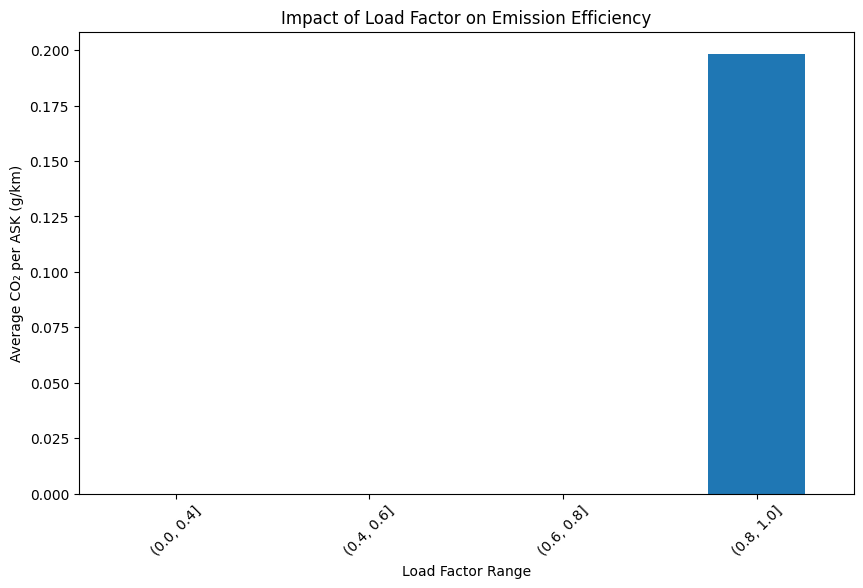

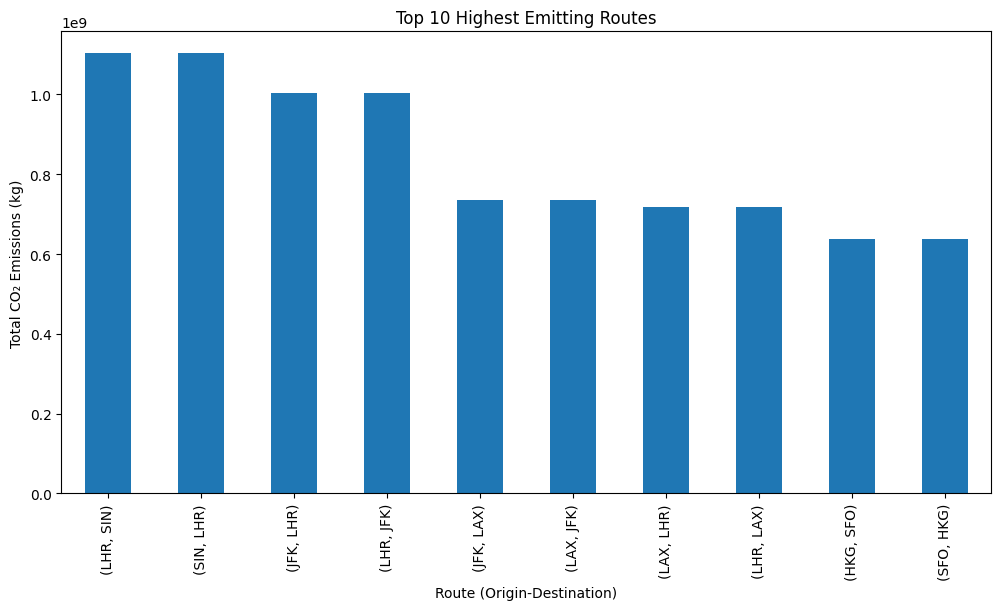

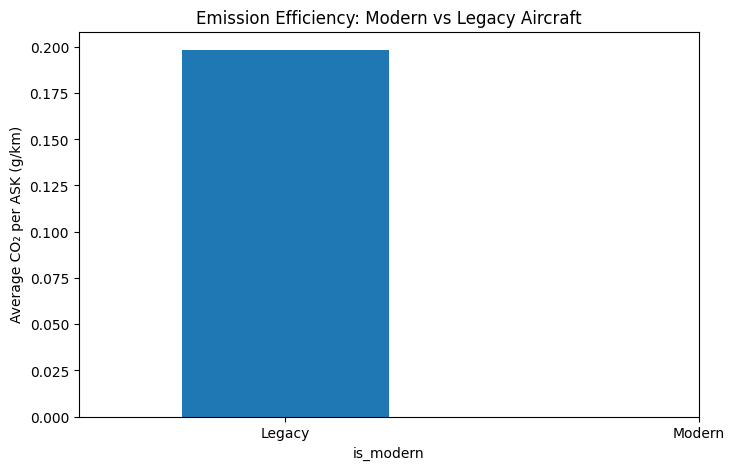

                            Value
Metric                           
Mean CO₂/ASK             0.2 g/km
Median Load Factor            82%
Max Route Emissions  1103150 tons


In [20]:
# 1. Emissions Distribution by Aircraft Class
plt.figure(figsize=(12,6))
sns.boxplot(x='acft_class', y='co2_per_ask', data=df)
plt.title('CO₂ Emission Efficiency by Aircraft Class')
plt.ylabel('CO₂ per Available Seat Kilometer (g/ASK)')
plt.xlabel('Aircraft Class')
plt.xticks(rotation=45)
plt.show()
plt.close()

# 2. Distance vs Fuel Efficiency
plt.figure(figsize=(10,6))
sns.scatterplot(x='distance_km', y='fuel_burn', hue='acft_class', 
                data=df, alpha=0.6, palette='viridis')
plt.title('Flight Distance vs Fuel Consumption')
plt.xlabel('Distance (km)')
plt.ylabel('Fuel Burn (kg)')
plt.show()
plt.close()

# 3. Load Factor Impact Analysis
bins = [0, 0.4, 0.6, 0.8, 1.0]
df['load_category'] = pd.cut(df['load_factor'], bins=bins)
load_factor_impact = df.groupby('load_category')['co2_per_ask'].mean()

plt.figure(figsize=(10,6))
load_factor_impact.plot(kind='bar')
plt.title('Impact of Load Factor on Emission Efficiency')
plt.xlabel('Load Factor Range')
plt.ylabel('Average CO₂ per ASK (g/km)')
plt.xticks(rotation=45)
plt.show()
plt.close()

# 4. Top 10 Emission Routes
top_routes = df.groupby(['iata_departure', 'iata_arrival'])['co2'].sum().nlargest(10)
plt.figure(figsize=(12,6))
top_routes.plot(kind='bar')

plt.title('Top 10 Highest Emitting Routes')
plt.ylabel('Total CO₂ Emissions (kg)')
plt.xlabel('Route (Origin-Destination)')
plt.show()
plt.close()

# 5. Aircraft Modernization Analysis
modern_aircraft = ['A350', 'B787', 'A320neo']
df['is_modern'] = df['seymour_proxy'].isin(modern_aircraft)

modern_efficiency = df.groupby('is_modern')['co2_per_ask'].mean()
plt.figure(figsize=(8,5))
modern_efficiency.plot(kind='bar')
plt.title('Emission Efficiency: Modern vs Legacy Aircraft')
plt.xticks([0,1], ['Legacy', 'Modern'], rotation=0)
plt.ylabel('Average CO₂ per ASK (g/km)')
plt.show()
plt.close()

# Generate Statistics Table
stats = pd.DataFrame({
    'Metric': ['Mean CO₂/ASK', 'Median Load Factor', 'Max Route Emissions'],
    'Value': [
        f"{df['co2_per_ask'].mean():.1f} g/km",
        f"{df['load_factor'].median()*100:.0f}%",
        f"{top_routes.max()/1000:.0f} tons"
    ]
}).set_index('Metric')

print(stats)

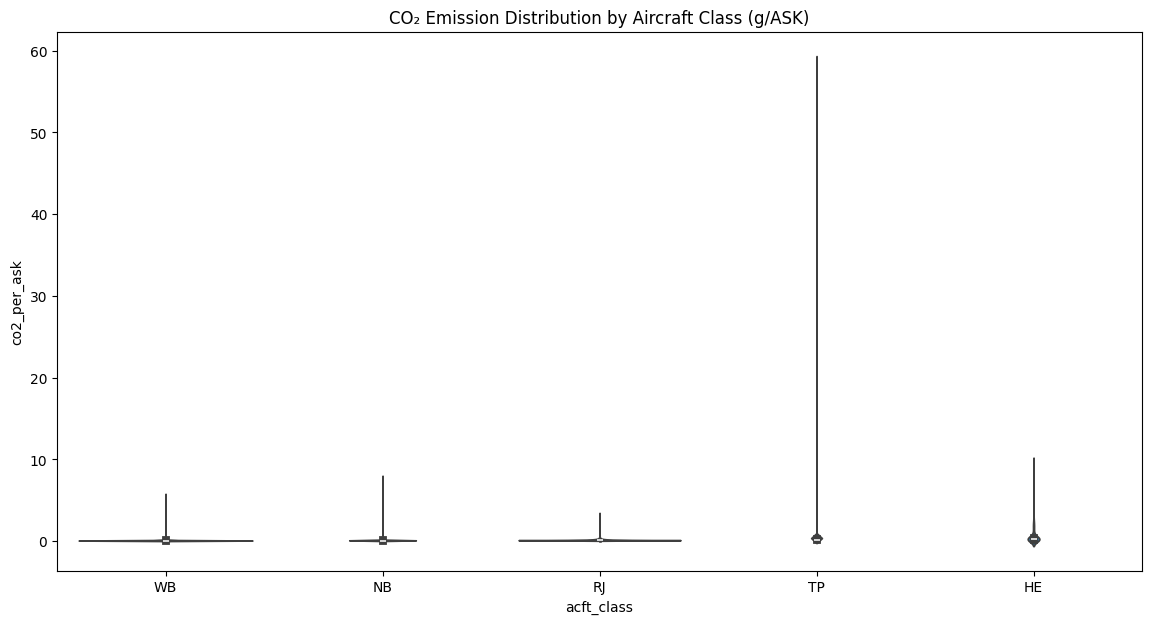

C:\Users\sakib\AppData\Local\Temp\ipykernel_13188\3360672953.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_anova = df[['acft_class','co2_per_ask']].groupby('acft_class').apply(lambda x: x.sample(min(len(x), 1000), replace=False))


ANOVA F-statistic: 20.867637321466365, p-value: 5.87938027791888e-28


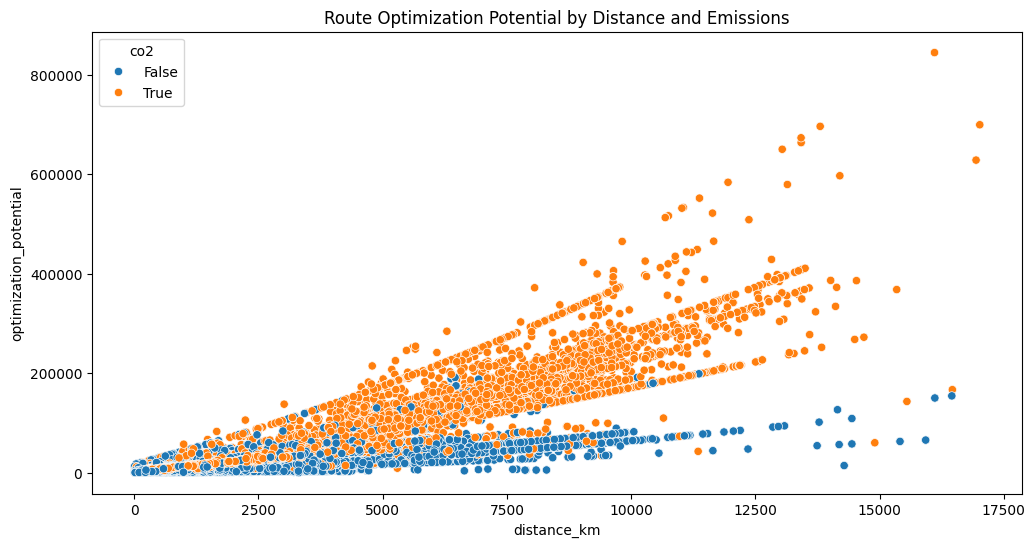

In [ ]:
# 1. Sustainability Impact by Aircraft Class
plt.figure(figsize=(14,7))
sns.violinplot(x='acft_class', y='co2_per_ask', data=df, 
              order=['WB','NB','RJ','TP','HE'])
plt.title('CO₂ Emission Distribution by Aircraft Class (g/ASK)')
plt.show()

# Statistical validation
# Ensure we don't sample more than available
class_anova = df[['acft_class','co2_per_ask']].groupby('acft_class').apply(lambda x: x.sample(min(len(x), 1000), replace=False))
# Perform ANOVA test
class_anova = class_anova.reset_index(level=0, drop=True)  # Reset index to avoid ambiguity
anova_result = f_oneway(*[group['co2_per_ask'] for name, group in class_anova.groupby('acft_class')])
print(f"ANOVA F-statistic: {anova_result.statistic}, p-value: {anova_result.pvalue}")


# 2. Route Optimization Potential
route_analysis = df.groupby(['iata_departure', 'iata_arrival']).agg({
    'distance_km': 'mean',
    'co2': 'sum',
    'n_flights': 'sum'
}).reset_index()
route_analysis['optimization_potential'] = route_analysis['co2'] / route_analysis['n_flights']

plt.figure(figsize=(12,6))
sns.scatterplot(x='distance_km', y='optimization_potential', data=route_analysis,
               hue=route_analysis['co2'] > 1e5)
plt.title('Route Optimization Potential by Distance and Emissions')
plt.show()

Model RMSE: 1.56


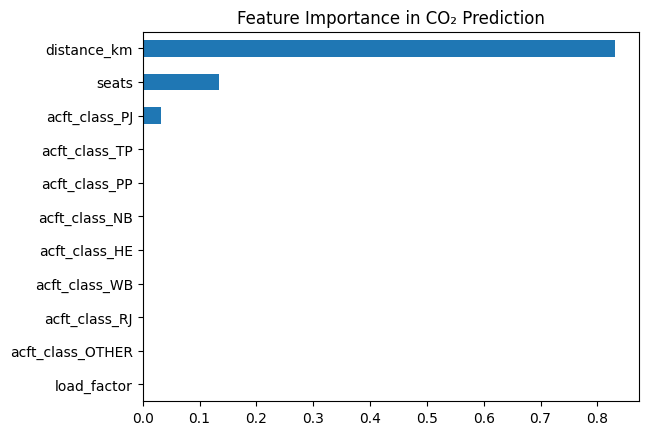

In [22]:

# 3. Machine Learning - Emission Prediction Model
features = ['distance_km', 'seats', 'acft_class', 'load_factor']
X = pd.get_dummies(df[features], columns=['acft_class'])
y = df['co2_per_ask']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(f'Model RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.2f}')

# Feature Importance
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title('Feature Importance in CO₂ Prediction')
plt.show()



C:\Users\sakib\AppData\Local\Temp\ipykernel_13188\251135556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='acft_class', y='mean_fuel_efficiency',


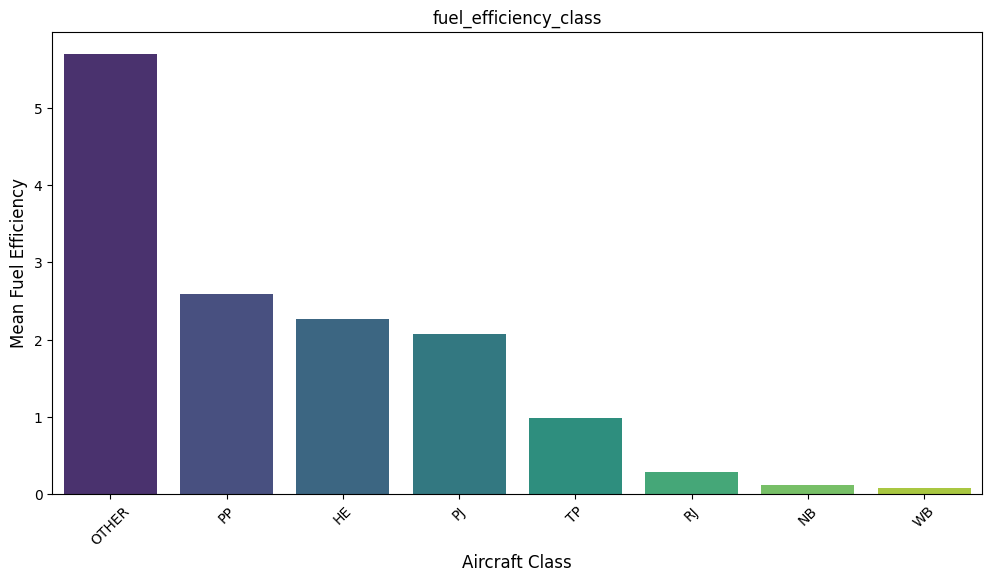

C:\Users\sakib\AppData\Local\Temp\ipykernel_13188\251135556.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='acft_class', y='co2_per_ask',


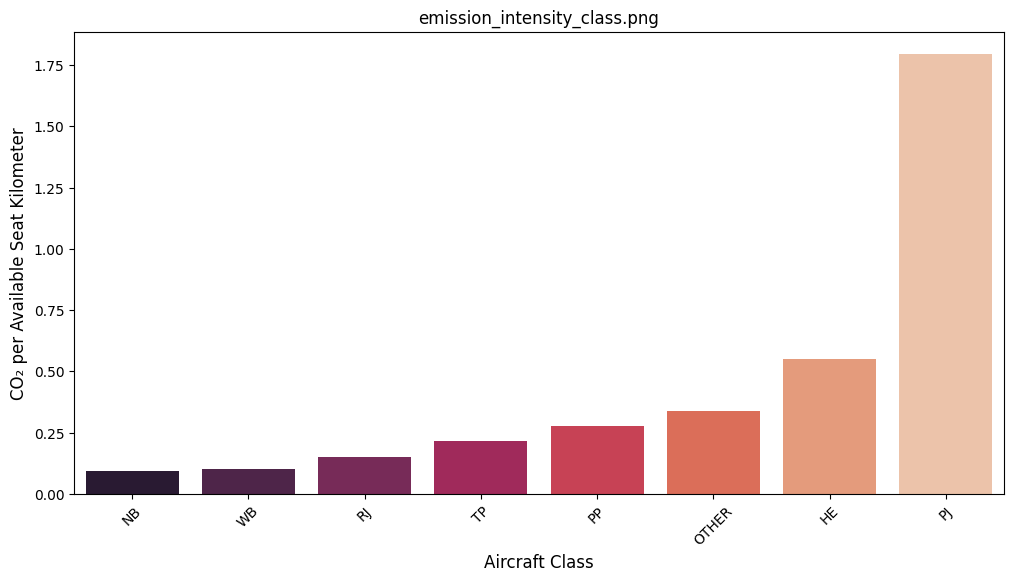

  acft_class  mean_fuel_efficiency  co2_per_ask  load_factor  \
2      OTHER              5.704287     0.339229        0.824   
4         PP              2.592895     0.276729        0.824   
6         TP              0.977517     0.214735        0.824   
0         HE              2.270616     0.549171        0.824   
5         RJ              0.282693     0.148174        0.824   
1         NB              0.110732     0.094665        0.824   
3         PJ              2.074477     1.796386        0.824   
7         WB              0.069470     0.101874        0.824   

   sustainability_score  
2             13.855920  
4              7.720719  
6              3.751020  
0              3.406933  
5              1.572058  
1              0.963859  
3              0.951560  
7              0.561905  


In [23]:
# Corrected Analysis with Sustainable Aviation Focus

# 1. Aircraft Class Efficiency Analysis
efficiency_by_class = df.groupby('acft_class').agg(
    mean_fuel_efficiency=('fuel_efficiency', 'mean'),
    co2_per_ask=('co2_per_ask', 'mean')
).reset_index()

# 2. Fuel Efficiency Visualization
plt.figure(figsize=(12,6))
sns.barplot(x='acft_class', y='mean_fuel_efficiency', 
            data=efficiency_by_class.sort_values('mean_fuel_efficiency', ascending=False),
            palette='viridis')
plt.title('Fuel Efficiency by Aircraft Class (km/kg fuel)', fontsize=14)
plt.xlabel('Aircraft Class', fontsize=12)
plt.ylabel('Mean Fuel Efficiency', fontsize=12)
plt.xticks(rotation=45)
plt.title('fuel_efficiency_class')
plt.show()
plt.close()

# 3. CO₂ Emission Intensity Analysis
plt.figure(figsize=(12,6))
sns.barplot(x='acft_class', y='co2_per_ask', 
            data=efficiency_by_class.sort_values('co2_per_ask'),
            palette='rocket')
plt.title('CO₂ Emission Intensity by Aircraft Class (g/ASK)', fontsize=14)
plt.xlabel('Aircraft Class', fontsize=12)
plt.ylabel('CO₂ per Available Seat Kilometer', fontsize=12)
plt.xticks(rotation=45)
plt.title('emission_intensity_class.png')
plt.show()
plt.close()

# 4. Sustainability Metrics Table
sustainability_table = efficiency_by_class.merge(
    df.groupby('acft_class')['load_factor'].mean().reset_index(),
    on='acft_class'
)
sustainability_table['sustainability_score'] = (
    sustainability_table['mean_fuel_efficiency'] * 
    sustainability_table['load_factor'] / 
    sustainability_table['co2_per_ask']
)


print(sustainability_table.sort_values('sustainability_score', ascending=False))
